# PRS PheWAS Analysis

## Data Source
This notebook uses a polygenic risk score (PRS) for hypercholesterolemia integrated with the All of Us cohort containing demographic, EHR, and ancestry covariates.

## Steps
- Load cohort data and merge with PRS values
- Standardize PRS and create analysis-ready cohort
- Define case/control groups using PRS thresholds (top and bottom deciles)
- Generate phecode counts from ICD codes using the PheTK workflow
- Run logistic-regression PheWAS with PRS-derived case status
- Adjust for age, sex, EHR length, and ancestry principal components (PC1–PC5)
- Visualize results using Manhattan plots
- Review top significant associations

## Results
The PRS PheWAS identified strong associations with lipid-related phenotypes, including hypercholesterolemia, mixed hyperlipidemia, and disorders of lipoprotein metabolism. Cardiovascular phenotypes such as coronary atherosclerosis and ischemic heart disease were also significantly associated, which is consistent with known biology.

## Output
This notebook produces multiple outputs including:
- `prs_cohort.tsv`
- `prs_top_decile_results.tsv`
- `prs_bottom_decile_results.tsv`
- Manhattan plots for each analysis

In [2]:
import pandas as pd
import os

df_cov = pd.read_csv("cohort.tsv", sep="\t")

prs = pd.read_csv("gs://fc-secure-45ad6977-e088-4b6b-b264-5260a12ff27a/data/hypercholesterolemia_PRS_adjusted.csv")

prs.columns = prs.columns.str.strip()
print(prs.columns.tolist())

prs = prs.rename(columns={
    "s": "person_id",
    "adjusted_score": "prs"
})

print(prs.columns.tolist())

prs["person_id"] = prs["person_id"].astype("int64")
df_cov["person_id"] = df_cov["person_id"].astype("int64")

cohort_df = df_cov.merge(prs[["person_id", "prs"]], on="person_id", how="inner")

cohort_df["prs"] = (cohort_df["prs"] - cohort_df["prs"].mean()) / cohort_df["prs"].std()

cohort_df = cohort_df.drop(columns=["case"])

print(cohort_df.head())
print(cohort_df.shape)
print(cohort_df["prs"].describe())
print(cohort_df.columns.tolist())

cohort_df.to_csv("prs_cohort.tsv", sep="\t", index=False)

['score', 'adjusted_score', 'condition', 'ancestry_pred', 's']
['score', 'prs', 'condition', 'ancestry_pred', 'person_id']
   person_id  age  ehr_length      pc_1      pc_2      pc_3      pc_4  \
0    1583400   48        1895  0.094543 -0.024477  0.028243  0.025669   
1    9518744   68        6394  0.099380  0.131129  0.010532  0.050819   
2    2097469   26         222  0.083695 -0.031694 -0.186943 -0.012876   
3    2916243   41         284  0.075633  0.020665 -0.125304  0.001577   
4    1190350   34        1023  0.095369  0.132594  0.010661  0.052256   

       pc_5  sex       prs  
0 -0.001694    1 -0.864143  
1  0.002063    1 -0.081147  
2 -0.000677    1  0.044910  
3  0.000184    1 -0.295083  
4  0.003133    1 -0.888780  
(225606, 10)
count    2.256060e+05
mean     4.480143e-18
std      1.000000e+00
min     -5.667562e+00
25%     -6.491585e-01
50%      2.944738e-02
75%      6.783456e-01
max      4.122975e+00
Name: prs, dtype: float64
['person_id', 'age', 'ehr_length', 'pc_1', 'pc_2'

In [4]:
from phetk.phecode import Phecode
from phetk.phewas import PheWAS
from phetk.plot import Plot

In [4]:
from phetk.phewas import PheWAS

phewas = PheWAS(
    phecode_version="X",
    phecode_count_file_path="phecode_counts.tsv",
    cohort_file_path="prs_cohort.tsv",
    covariate_cols=["age", "sex", "ehr_length", "pc_1", "pc_2", "pc_3", "pc_4", "pc_5"],
    independent_variable_of_interest="prs",
    sex_at_birth_col="sex",
    min_cases=50,
    min_phecode_count=2,
    method="logit",
    output_file_path="prs_phewas_results.tsv"
)

phewas.run()

~~~~~~~~~~~~~~~~~~~~~~~~    Creating PheWAS Instance    ~~~~~~~~~~~~~~~~~~~~~~~~

Cohort size:  225606
prs descriptions:  shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 225606.0   │
│ null_count ┆ 0.0        │
│ mean       ┆ 4.5857e-17 │
│ std        ┆ 1.0        │
│ min        ┆ -5.667562  │
│ 25%        ┆ -0.64917   │
│ 50%        ┆ 0.029449   │
│ 75%        ┆ 0.678356   │
│ max        ┆ 4.122975   │
└────────────┴────────────┘

Number of unique phecodes in cohort:  3508
Total number of phecode events:  16788066
Number of phecode batches to process:  3508

Analysis method:  Logistic regression

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~    Running PheWAS    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Parallelization method: multithreading
Number of workers: 3

Creating ThreadPoolExecutor...
Submitting jobs to workers...
Submitted 3508 jobs. Running regressions...


Processed: 100%|██████████| 3508/3508 [58:38<00:00,  1.00s/it]  


Multithreading completed successfully.
Combining 2440 result files...


Reading files: 100%|██████████| 2440/2440 [00:03<00:00, 780.61it/s]


Concatenating results...
Cleaning up temporary files...


Cleaning files: 100%|██████████| 2440/2440 [00:00<00:00, 42450.36it/s]



~~~~~~~~~~~~~~~~~~~~~~~~~~~~    PheWAS Completed    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Number of participants in cohort: 225606
Number of phecodes in cohort: 3508
Number of phecodes having less than 50 cases or controls: 1068
Number of phecodes tested: 2440
Suggested Bonferroni correction (-log₁₀ scale): 4.688419822002711
Number of phecodes above Bonferroni correction: 28

PheWAS results saved to prs_phewas_results.tsv 




Plot saved to prs_manhattan_plot.png



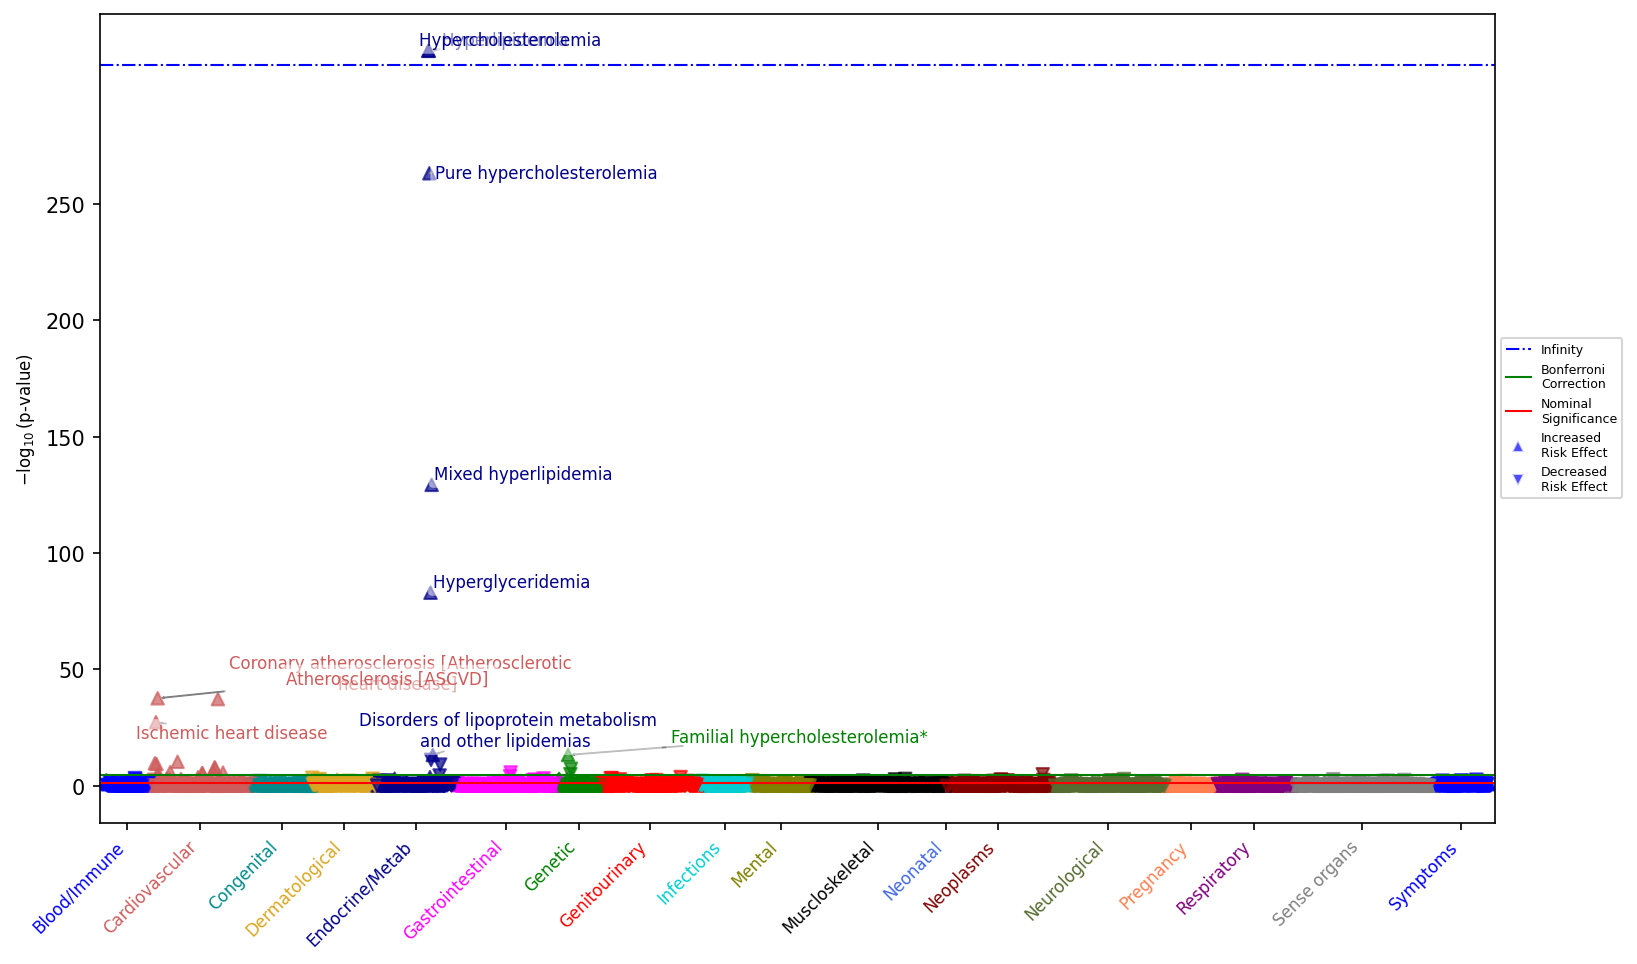

In [5]:
from phetk.plot import Plot

p = Plot("prs_phewas_results.tsv", converged_only=True)

p.manhattan(
    label_values="p_value",
    label_count=10,
    save_plot=True,
    output_file_path="prs_manhattan_plot.png"
)

In [6]:
results = pd.read_csv("prs_phewas_results.tsv", sep="\t")
results_clean = results[results["converged"] == True].sort_values("p_value")
results_clean.head(20)

,phecode,cases,controls,p_value,neg_log_p_value,standard_error,beta,conf_int_1,conf_int_2,odds_ratio,log10_odds_ratio,converged,phecode_sex_restriction,phecode_string,phecode_category
2271,EM_239.1,48220,165563,0.000000e+00,inf,0.006,0.237379,0.226,0.249,1.267921,0.103092,True,Both,Hypercholesterolemia,Endocrine/Metab
1885,EM_239,88020,124353,0.000000e+00,inf,0.005,0.257206,0.247,0.268,1.293311,0.111703,True,Both,Hyperlipidemia,Endocrine/Metab
625,EM_239.11,29052,186035,8.032207e-264,263.095165,0.007,0.241605,0.228,0.255,1.273292,0.104928,True,Both,Pure hypercholesterolemia,Endocrine/Metab
44,EM_239.3,25645,192955,5.532962e-130,129.257042,0.007,0.169850,0.156,0.184,1.185127,0.073765,True,Both,Mixed hyperlipidemia,Endocrine/Metab
1178,EM_239.2,29267,188034,1.196943e-83,82.921926,0.007,0.127895,0.115,0.141,1.136434,0.055544,True,Both,Hyperglyceridemia,Endocrine/Metab
1183,CV_404.2,24005,194416,2.645126e-38,37.577554,0.007,0.096356,0.082,0.111,1.101151,0.041847,True,Both,Coronary atherosclerosis [Atherosclerotic hear...,Cardiovascular
231,CV_436,27250,189355,5.800365e-38,37.236545,0.007,0.091720,0.078,0.106,1.096058,0.039834,True,Both,Atherosclerosis [ASCVD],Cardiovascular
1272,CV_404,26914,190402,4.994428e-28,27.301514,0.007,0.077641,0.064,0.092,1.080735,0.033719,True,Both,Ischemic heart disease,Cardiovascular
207,GE_965.4,475,224842,5.649270e-14,13.248008,0.047,0.354605,0.262,0.447,1.425617,0.154003,True,Both,Familial hypercholesterolemia*,Genetic
2300,EM_244,2820,218990,5.831116e-14,13.234248,0.020,0.146885,0.109,0.185,1.158221,0.063791,True,Both,Disorders of lipoprotein metabolism and other ...,Endocrine/Metab


In [1]:
import pandas as pd

results = pd.read_csv("prs_phewas_results.tsv", sep="\t")
results_clean = results[results["converged"] == True].sort_values("p_value")
results_clean.head(20)

,phecode,cases,controls,p_value,neg_log_p_value,standard_error,beta,conf_int_1,conf_int_2,odds_ratio,log10_odds_ratio,converged,phecode_sex_restriction,phecode_string,phecode_category
2271,EM_239.1,48220,165563,0.000000e+00,inf,0.006,0.237379,0.226,0.249,1.267921,0.103092,True,Both,Hypercholesterolemia,Endocrine/Metab
1885,EM_239,88020,124353,0.000000e+00,inf,0.005,0.257206,0.247,0.268,1.293311,0.111703,True,Both,Hyperlipidemia,Endocrine/Metab
625,EM_239.11,29052,186035,8.032207e-264,263.095165,0.007,0.241605,0.228,0.255,1.273292,0.104928,True,Both,Pure hypercholesterolemia,Endocrine/Metab
44,EM_239.3,25645,192955,5.532962e-130,129.257042,0.007,0.169850,0.156,0.184,1.185127,0.073765,True,Both,Mixed hyperlipidemia,Endocrine/Metab
1178,EM_239.2,29267,188034,1.196943e-83,82.921926,0.007,0.127895,0.115,0.141,1.136434,0.055544,True,Both,Hyperglyceridemia,Endocrine/Metab
1183,CV_404.2,24005,194416,2.645126e-38,37.577554,0.007,0.096356,0.082,0.111,1.101151,0.041847,True,Both,Coronary atherosclerosis [Atherosclerotic hear...,Cardiovascular
231,CV_436,27250,189355,5.800365e-38,37.236545,0.007,0.091720,0.078,0.106,1.096058,0.039834,True,Both,Atherosclerosis [ASCVD],Cardiovascular
1272,CV_404,26914,190402,4.994428e-28,27.301514,0.007,0.077641,0.064,0.092,1.080735,0.033719,True,Both,Ischemic heart disease,Cardiovascular
207,GE_965.4,475,224842,5.649270e-14,13.248008,0.047,0.354605,0.262,0.447,1.425617,0.154003,True,Both,Familial hypercholesterolemia*,Genetic
2300,EM_244,2820,218990,5.831116e-14,13.234248,0.020,0.146885,0.109,0.185,1.158221,0.063791,True,Both,Disorders of lipoprotein metabolism and other ...,Endocrine/Metab


In [2]:
import pandas as pd

df = pd.read_csv("prs_cohort.tsv", sep="\t")

# define thresholds
top_threshold = df["prs"].quantile(0.9)
mid_low = df["prs"].quantile(0.4)
mid_high = df["prs"].quantile(0.6)

# create case/control
df["case"] = None
df.loc[df["prs"] >= top_threshold, "case"] = 1
df.loc[(df["prs"] >= mid_low) & (df["prs"] <= mid_high), "case"] = 0

# drop others
df_top = df.dropna(subset=["case"])

print(df_top["case"].value_counts())
df_top.to_csv("prs_top_decile_cohort.tsv", sep="\t", index=False)

case
0    45122
1    22561
Name: count, dtype: int64


In [5]:
phewas = PheWAS(
    phecode_version="X",
    phecode_count_file_path="phecode_counts.tsv",
    cohort_file_path="prs_top_decile_cohort.tsv",
    covariate_cols=["age", "sex", "ehr_length", "pc_1", "pc_2", "pc_3", "pc_4", "pc_5"],
    independent_variable_of_interest="case",
    sex_at_birth_col="sex",
    min_cases=50,
    min_phecode_count=2,
    method="logit",
    output_file_path="prs_top_decile_results.tsv"
)

phewas.run()

~~~~~~~~~~~~~~~~~~~~~~~~    Creating PheWAS Instance    ~~~~~~~~~~~~~~~~~~~~~~~~

Cohort size:  67683
case descriptions:  shape: (2, 2)
┌──────┬───────┐
│ case ┆ count │
│ ---  ┆ ---   │
│ i64  ┆ u32   │
╞══════╪═══════╡
│ 0    ┆ 45122 │
│ 1    ┆ 22561 │
└──────┴───────┘

Number of unique phecodes in cohort:  3404
Total number of phecode events:  5057369
Number of phecode batches to process:  3404

Analysis method:  Logistic regression

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~    Running PheWAS    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Parallelization method: multithreading
Number of workers: 3

Creating ThreadPoolExecutor...
Submitting jobs to workers...
Submitted 3404 jobs. Running regressions...


Processed: 100%|██████████| 3404/3404 [19:26<00:00,  2.92it/s]


Multithreading completed successfully.
Combining 1964 result files...


Reading files: 100%|██████████| 1964/1964 [00:02<00:00, 807.79it/s]


Concatenating results...
Cleaning up temporary files...


Cleaning files: 100%|██████████| 1964/1964 [00:00<00:00, 41742.62it/s]



~~~~~~~~~~~~~~~~~~~~~~~~~~~~    PheWAS Completed    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Number of participants in cohort: 67683
Number of phecodes in cohort: 3404
Number of phecodes having less than 50 cases or controls: 1440
Number of phecodes tested: 1964
Suggested Bonferroni correction (-log₁₀ scale): 4.594171479114912
Number of phecodes above Bonferroni correction: 10

PheWAS results saved to prs_top_decile_results.tsv 




Plot saved to prs_top_decile_manhattan.png



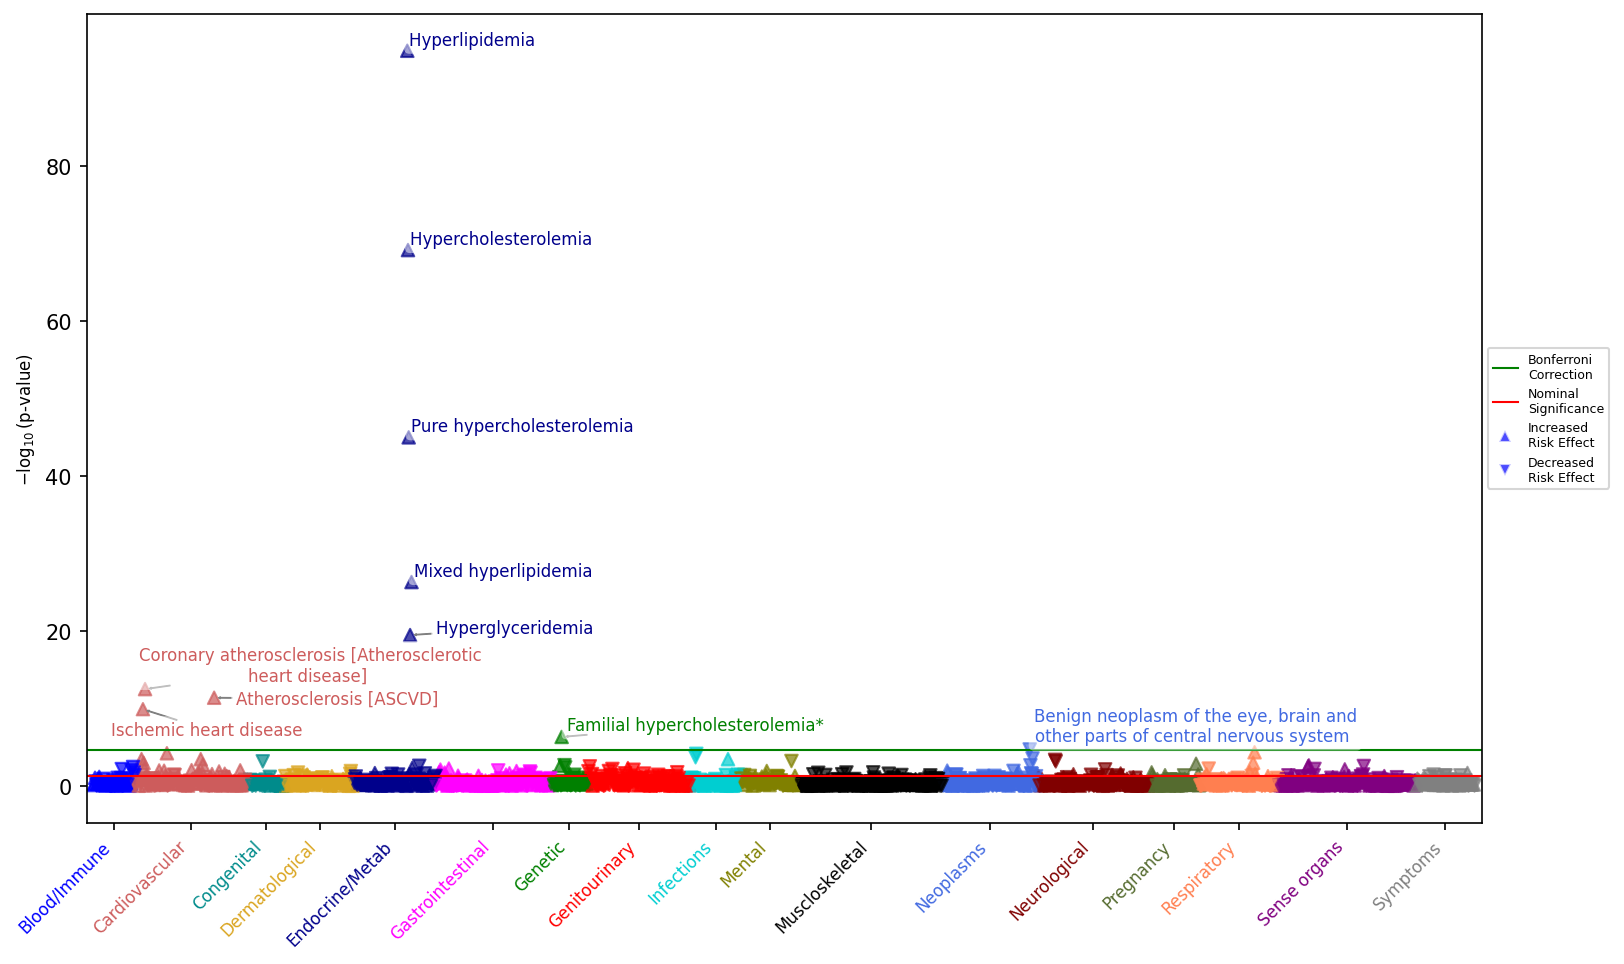

In [6]:
from phetk.plot import Plot

p = Plot("prs_top_decile_results.tsv", converged_only=True)

p.manhattan(
    label_values="p_value",
    label_count=10,
    save_plot=True,
    output_file_path="prs_top_decile_manhattan.png"
)

In [7]:
results = pd.read_csv("prs_top_decile_results.tsv", sep="\t")
results_clean = results[results["converged"] == True].sort_values("p_value")
results_clean.head(20)

,phecode,cases,controls,p_value,neg_log_p_value,standard_error,beta,conf_int_1,conf_int_2,odds_ratio,log10_odds_ratio,converged,phecode_sex_restriction,phecode_string,phecode_category
1626,EM_239,28124,35522,1.574419e-95,94.802880,0.020,0.420785,0.381,0.461,1.523157,0.182745,True,Both,Hyperlipidemia,Endocrine/Metab
1587,EM_239.1,15622,48356,8.018211e-70,69.095923,0.021,0.376949,0.335,0.419,1.457830,0.163707,True,Both,Hypercholesterolemia,Endocrine/Metab
487,EM_239.11,9692,54632,1.149187e-45,44.939609,0.025,0.351546,0.303,0.400,1.421264,0.152675,True,Both,Pure hypercholesterolemia,Endocrine/Metab
746,EM_239.3,8158,57292,5.328914e-27,26.273361,0.026,0.274903,0.225,0.325,1.316403,0.119389,True,Both,Mixed hyperlipidemia,Endocrine/Metab
799,EM_239.2,9175,55940,3.651011e-20,19.437587,0.024,0.224940,0.177,0.273,1.252247,0.097690,True,Both,Hyperglyceridemia,Endocrine/Metab
1808,CV_404.2,7523,58004,3.406031e-13,12.467751,0.028,0.202160,0.148,0.257,1.224044,0.087797,True,Both,Coronary atherosclerosis [Atherosclerotic hear...,Cardiovascular
1081,CV_436,8517,56417,4.429080e-12,11.353687,0.027,0.184667,0.132,0.237,1.202817,0.080200,True,Both,Atherosclerosis [ASCVD],Cardiovascular
1139,CV_404,8333,56830,1.354293e-10,9.868287,0.027,0.171207,0.119,0.223,1.186736,0.074354,True,Both,Ischemic heart disease,Cardiovascular
1609,GE_965.4,178,67390,5.016510e-07,6.299598,0.150,0.755392,0.461,1.050,2.128447,0.328063,True,Both,Familial hypercholesterolemia*,Genetic
596,CA_148,1201,66038,2.069482e-05,4.684138,0.066,-0.280708,-0.410,-0.151,0.755249,-0.121910,True,Both,"Benign neoplasm of the eye, brain and other pa...",Neoplasms


In [8]:
import pandas as pd

df = pd.read_csv("prs_cohort.tsv", sep="\t")

# thresholds (same middle)
bottom_threshold = df["prs"].quantile(0.1)
mid_low = df["prs"].quantile(0.4)
mid_high = df["prs"].quantile(0.6)

df["case"] = None
df.loc[df["prs"] <= bottom_threshold, "case"] = 1
df.loc[(df["prs"] >= mid_low) & (df["prs"] <= mid_high), "case"] = 0

df_bottom = df.dropna(subset=["case"])
df_bottom["case"] = df_bottom["case"].astype(int)

print(df_bottom["case"].value_counts())

df_bottom.to_csv("prs_bottom_decile_cohort.tsv", sep="\t", index=False)

case
0    45122
1    22561
Name: count, dtype: int64


In [9]:
from phetk.phewas import PheWAS

phewas = PheWAS(
    phecode_version="X",
    phecode_count_file_path="phecode_counts.tsv",
    cohort_file_path="prs_bottom_decile_cohort.tsv",
    covariate_cols=["age", "sex", "ehr_length", "pc_1", "pc_2", "pc_3", "pc_4", "pc_5"],
    independent_variable_of_interest="case",
    sex_at_birth_col="sex",
    min_cases=50,
    min_phecode_count=2,
    method="logit",
    output_file_path="prs_bottom_decile_results.tsv"
)

phewas.run()

~~~~~~~~~~~~~~~~~~~~~~~~    Creating PheWAS Instance    ~~~~~~~~~~~~~~~~~~~~~~~~

Cohort size:  67683
case descriptions:  shape: (2, 2)
┌──────┬───────┐
│ case ┆ count │
│ ---  ┆ ---   │
│ i64  ┆ u32   │
╞══════╪═══════╡
│ 0    ┆ 45122 │
│ 1    ┆ 22561 │
└──────┴───────┘

Number of unique phecodes in cohort:  3395
Total number of phecode events:  5077794
Number of phecode batches to process:  3395

Analysis method:  Logistic regression

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~    Running PheWAS    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Parallelization method: multithreading
Number of workers: 3

Creating ThreadPoolExecutor...
Submitting jobs to workers...
Submitted 3395 jobs. Running regressions...


Processed: 100%|██████████| 3395/3395 [18:46<00:00,  3.01it/s]


Multithreading completed successfully.
Combining 1968 result files...


Reading files: 100%|██████████| 1968/1968 [00:01<00:00, 992.79it/s] 


Concatenating results...
Cleaning up temporary files...


Cleaning files: 100%|██████████| 1968/1968 [00:00<00:00, 45657.84it/s]


~~~~~~~~~~~~~~~~~~~~~~~~~~~~    PheWAS Completed    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Number of participants in cohort: 67683
Number of phecodes in cohort: 3395
Number of phecodes having less than 50 cases or controls: 1427
Number of phecodes tested: 1968
Suggested Bonferroni correction (-log₁₀ scale): 4.595055089759304
Number of phecodes above Bonferroni correction: 9

PheWAS results saved to prs_bottom_decile_results.tsv 




Plot saved to prs_bottom_decile_manhattan.png



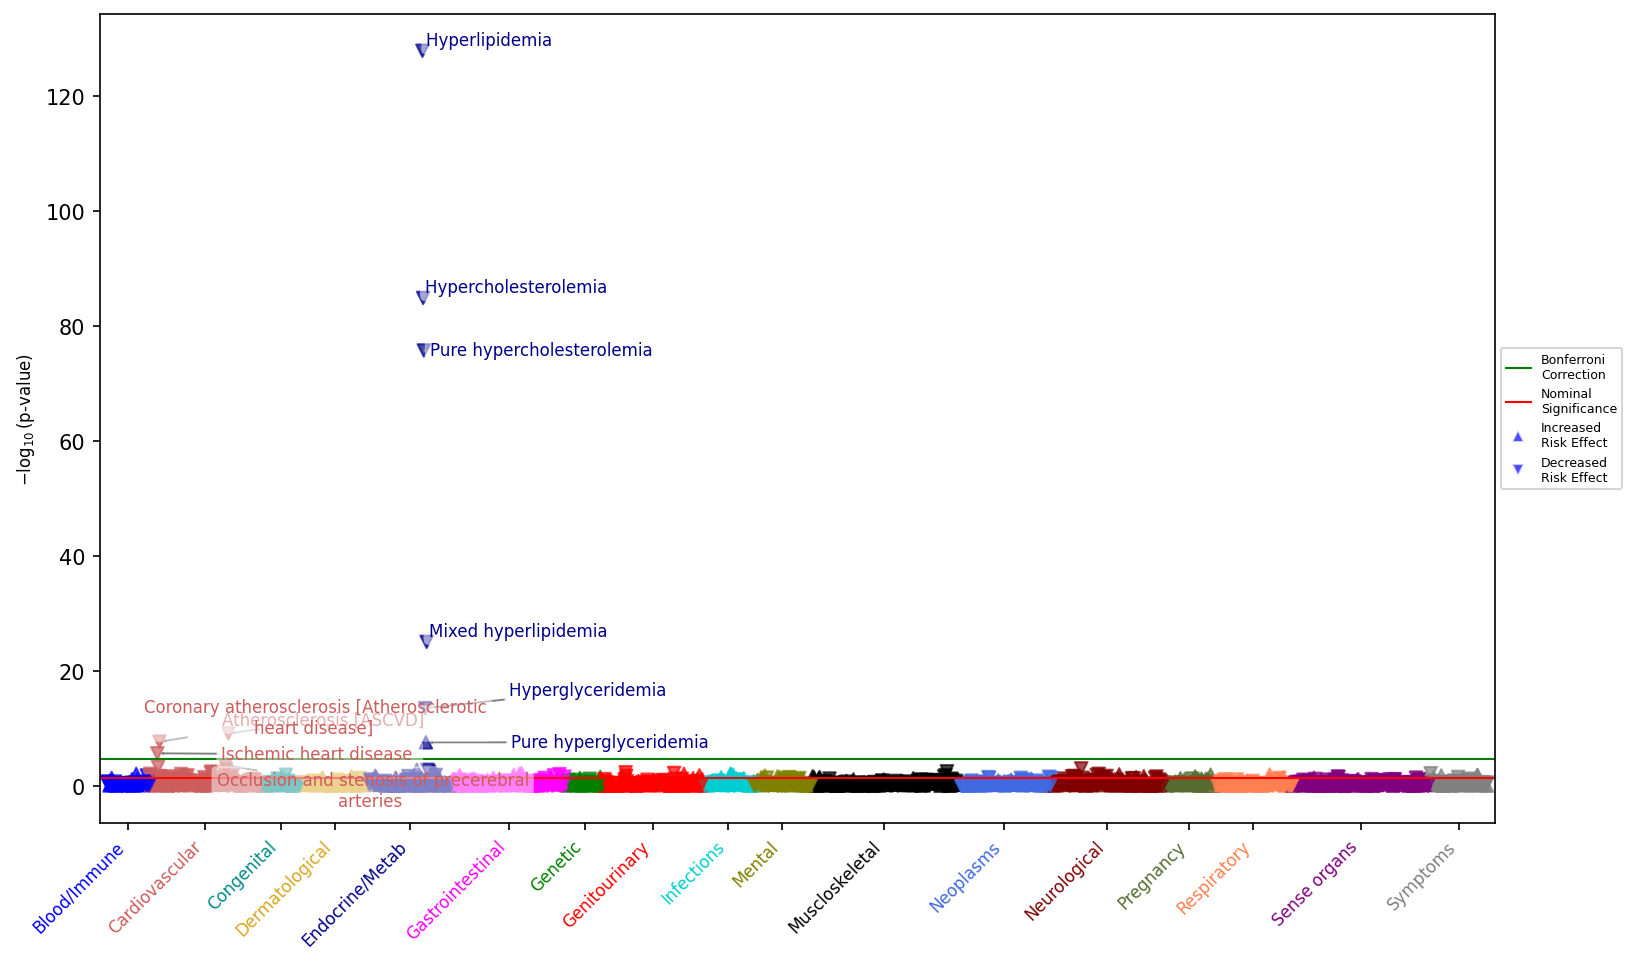

In [10]:
from phetk.plot import Plot

p = Plot("prs_bottom_decile_results.tsv", converged_only=True)

p.manhattan(
    label_values="p_value",
    label_count=10,
    save_plot=True,
    output_file_path="prs_bottom_decile_manhattan.png"
)

In [11]:
import pandas as pd

results = pd.read_csv("prs_bottom_decile_results.tsv", sep="\t")
results_clean = results[results["converged"] == True].sort_values("p_value")
results_clean.head(20)

,phecode,cases,controls,p_value,neg_log_p_value,standard_error,beta,conf_int_1,conf_int_2,odds_ratio,log10_odds_ratio,converged,phecode_sex_restriction,phecode_string,phecode_category
513,EM_239,24952,38743,1.142181e-128,127.942265,0.021,-0.499484,-0.540,-0.459,0.606844,-0.216923,True,Both,Hyperlipidemia,Endocrine/Metab
359,EM_239.1,13315,50996,1.212078e-85,84.916469,0.024,-0.462915,-0.509,-0.417,0.629446,-0.201042,True,Both,Hypercholesterolemia,Endocrine/Metab
1751,EM_239.11,8002,56728,1.677642e-76,75.775301,0.029,-0.538225,-0.595,-0.481,0.583783,-0.233748,True,Both,Pure hypercholesterolemia,Endocrine/Metab
539,EM_239.3,7089,58612,8.953802e-26,25.047993,0.029,-0.301382,-0.358,-0.245,0.739795,-0.130888,True,Both,Mixed hyperlipidemia,Endocrine/Metab
1565,EM_239.2,8296,57004,3.145514e-14,13.502308,0.026,-0.200925,-0.253,-0.149,0.817974,-0.087261,True,Both,Hyperglyceridemia,Endocrine/Metab
423,CV_436,7941,57018,7.944582e-10,9.099929,0.028,-0.172412,-0.227,-0.117,0.841633,-0.074877,True,Both,Atherosclerosis [ASCVD],Cardiovascular
792,CV_404.2,6967,58587,2.109675e-08,7.675784,0.029,-0.164702,-0.222,-0.107,0.848146,-0.071529,True,Both,Coronary atherosclerosis [Atherosclerotic hear...,Cardiovascular
990,EM_239.21,1597,65135,2.778479e-08,7.556193,0.052,0.289621,0.187,0.392,1.335922,0.125781,True,Both,Pure hyperglyceridemia,Endocrine/Metab
930,CV_404,7855,57353,2.252417e-06,5.647351,0.028,-0.131330,-0.186,-0.077,0.876928,-0.057036,True,Both,Ischemic heart disease,Cardiovascular
800,CV_433.2,1481,65136,2.438763e-04,3.612830,0.059,-0.214695,-0.329,-0.100,0.806787,-0.093241,True,Both,Occlusion and stenosis of precerebral arteries,Cardiovascular
